In [1]:
import os
import cv2
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from torchinfo import summary
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import lab2rgb
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

In [2]:
class ColorizationDataset(Dataset):
    def __init__(self, gray_dir, color_dir, image_size=256):
        self.gray_dir = gray_dir
        self.color_dir = color_dir
        self.image_size = image_size

        self.filenames = sorted([f for f in os.listdir(self.gray_dir) if f.endswith(".jpg")])

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        filename = self.filenames[idx]

        gray = cv2.imread(os.path.join(self.gray_dir, filename), cv2.IMREAD_GRAYSCALE)
        color = cv2.imread(os.path.join(self.color_dir, filename))
        color = cv2.cvtColor(color, cv2.COLOR_BGR2RGB)

        # Resize
        gray = cv2.resize(gray, (self.image_size, self.image_size))
        color = cv2.resize(color, (self.image_size, self.image_size))

        # Convert to LAB
        lab = cv2.cvtColor(color, cv2.COLOR_RGB2LAB).astype(np.float32)

        L = lab[:, :, 0]         # [0–255]
        ab = lab[:, :, 1:]       # [0–255]

        # Normalize to [-1,1] 
        L = (L / 255.0) * 2 - 1
        ab = (ab / 255.0) * 2 - 1

        L = torch.tensor(L).unsqueeze(0).float()
        ab = torch.tensor(ab).permute(2,0,1).float()

        return L, ab


In [3]:
train_dataset = ColorizationDataset(
    gray_dir="dataset/data/train_black",
    color_dir="dataset/data/train_color"
)
test_dataset = ColorizationDataset(
    gray_dir="dataset/data/test_black",
    color_dir="dataset/data/test_color"
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [4]:
def show_sample(L, ab):
    L = L.squeeze().numpy()        # [256,256]
    ab = ab.numpy().transpose(1,2,0)   # [256,256,2]

    # Denormalize
    L = ((L + 1) / 2) * 255
    ab = ((ab + 1) / 2) * 255

    lab = np.zeros((256,256,3), dtype=np.float32)
    lab[:,:,0] = L
    lab[:,:,1:] = ab

    rgb = lab2rgb(lab)  

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.title("Grayscale L")
    plt.imshow(L, cmap="gray")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title("Ground Truth")
    plt.imshow(rgb)
    plt.axis("off")
    plt.show()

In [5]:
class ColorizationAutoencoder(nn.Module):
    def __init__(self):
        super(ColorizationAutoencoder, self).__init__()

        # ENCODER
        self.enc1 = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )  # 256x256

        self.enc2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )  # 128x128

        self.enc3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )  # 64x64

        self.enc4 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU()
        )  # 32x32

        # DECODER
        self.dec4 = nn.Sequential(
            nn.ConvTranspose2d(512, 256, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )  # 64x64

        self.dec3 = nn.Sequential(
            nn.ConvTranspose2d(512, 128, kernel_size=3, stride=2, padding=1, output_padding=1), 
            nn.BatchNorm2d(128),
            nn.ReLU()
        )  # 128x128

        self.dec2 = nn.Sequential(
            nn.ConvTranspose2d(256, 64, kernel_size=3, stride=2, padding=1, output_padding=1), 
            nn.BatchNorm2d(64),
            nn.ReLU()
        )  # 256x256

        self.dec1 = nn.Sequential(
            nn.Conv2d(128, 2, kernel_size=3, stride=1, padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)

        # Decoder with skip connections
        d4 = self.dec4(e4)               # 64x64
        d4 = torch.cat([d4, e3], dim=1)  

        d3 = self.dec3(d4)               # 128x128
        d3 = torch.cat([d3, e2], dim=1)

        d2 = self.dec2(d3)               # 256x256
        d2 = torch.cat([d2, e1], dim=1)

        out = self.dec1(d2)              # 2 channels ab

        return out


In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = ColorizationAutoencoder().to(device)

In [7]:
# Test forward
L_batch, ab_batch = next(iter(train_loader))
L_batch = L_batch.to(device)
ab_batch = ab_batch.to(device)
output = model(L_batch)
output.shape

torch.Size([16, 2, 256, 256])

In [8]:
criterion = nn.SmoothL1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [9]:
num_epochs = 10

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    
# TRAINING
    
    model.train()
    train_loss = 0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} (Training)")

    for L, ab in loop:
        L = L.to(device)
        ab = ab.to(device)

        optimizer.zero_grad()
        output = model(L)

        loss = criterion(output, ab)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

# VALIDATION
    
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for L, ab in test_loader:
            L = L.to(device)
            ab = ab.to(device)

            output = model(L)
            loss = criterion(output, ab)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(test_loader)
    val_losses.append(avg_val_loss)

 
    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f}")

Epoch 1/10 (Training): 100%|███████████████████████████████████████████| 313/313 [01:01<00:00,  5.09it/s, loss=0.00721]


Epoch [1/10] Train Loss: 0.0084 | Val Loss: 0.0065


Epoch 2/10 (Training): 100%|███████████████████████████████████████████| 313/313 [00:58<00:00,  5.37it/s, loss=0.00354]


Epoch [2/10] Train Loss: 0.0066 | Val Loss: 0.0064


Epoch 3/10 (Training): 100%|███████████████████████████████████████████| 313/313 [00:57<00:00,  5.41it/s, loss=0.00454]


...

Epoch [8/10] Train Loss: 0.0062 | Val Loss: 0.0061


Epoch 9/10 (Training): 100%|███████████████████████████████████████████| 313/313 [00:57<00:00,  5.41it/s, loss=0.00693]


Epoch [9/10] Train Loss: 0.0062 | Val Loss: 0.0062


Epoch 10/10 (Training): 100%|██████████████████████████████████████████| 313/313 [00:57<00:00,  5.43it/s, loss=0.00558]


Epoch [10/10] Train Loss: 0.0062 | Val Loss: 0.0061


In [10]:
torch.save(model.state_dict(), "colorization_autoencoder_smoothL1.pth")

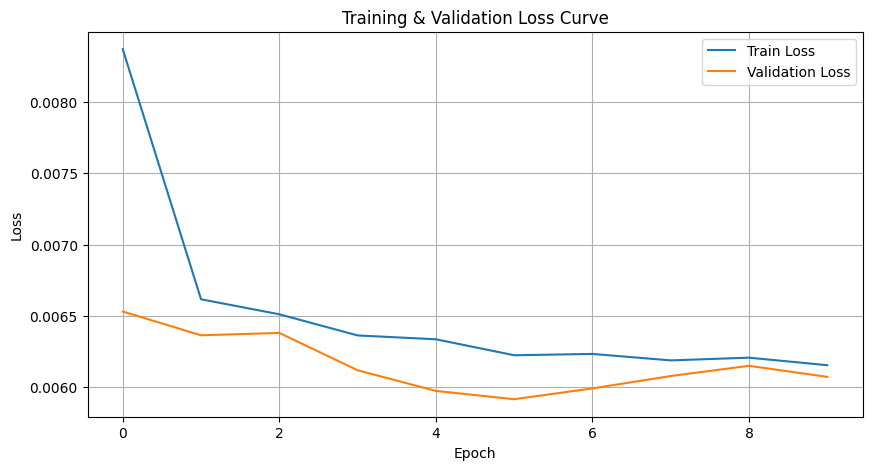

In [11]:
plt.figure(figsize=(10,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
def show_image_by_index(model, dataset, index, device='cuda'):
    model.eval()

    # Load sample
    L, ab_true = dataset[index]
    L = L.unsqueeze(0).to(device)
    ab_true = ab_true.unsqueeze(0).to(device)

    with torch.no_grad():
        ab_pred = model(L)

    # Convert to numpy
    L_np = L[0].cpu().numpy().squeeze()
    ab_true_np = ab_true[0].cpu().numpy().transpose(1, 2, 0)
    ab_pred_np = ab_pred[0].cpu().numpy().transpose(1, 2, 0)

    # Denormalize LAB
    L_img = (L_np + 1) * 50
    ab_true_img = ab_true_np * 128
    ab_pred_img = ab_pred_np * 128

    # Clamp to valid LAB ranges
    L_img = np.clip(L_img, 0, 100)
    ab_true_img = np.clip(ab_true_img, -128, 127)
    ab_pred_img = np.clip(ab_pred_img, -128, 127)

    # Build LAB arrays
    lab_true = np.dstack((L_img, ab_true_img))
    lab_pred = np.dstack((L_img, ab_pred_img))

    # Convert to RGB
    rgb_true = lab2rgb(lab_true.astype(np.float32))
    rgb_pred = lab2rgb(lab_pred.astype(np.float32))

    # Plot
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 3, 1)
    plt.title("Input L (Grayscale)")
    plt.imshow(L_img / 100, cmap="gray")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title("Ground Truth")
    plt.imshow(rgb_true)
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title("Prediction")
    plt.imshow(rgb_pred)
    plt.axis("off")

    plt.show()

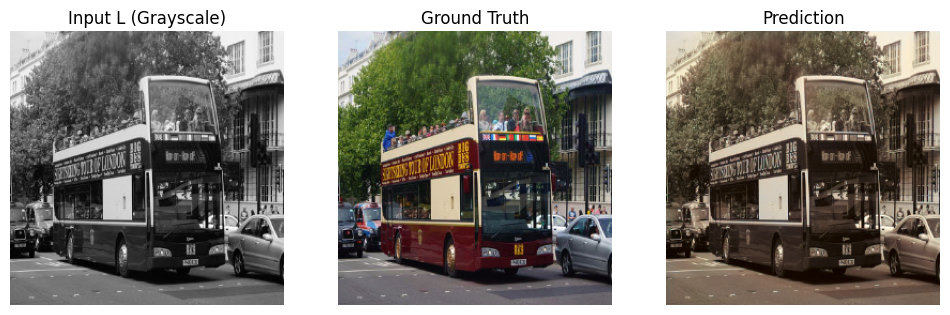

In [13]:
show_image_by_index(model, test_dataset,index=22)

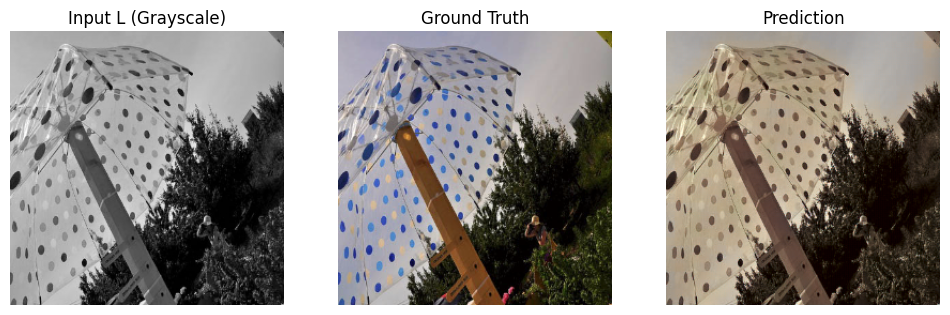

In [14]:
show_image_by_index(model, test_dataset,index=12)

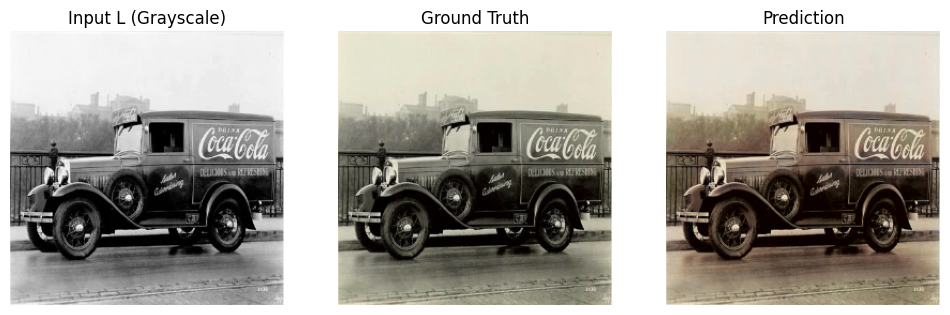

In [15]:
show_image_by_index(model, test_dataset,index=18)

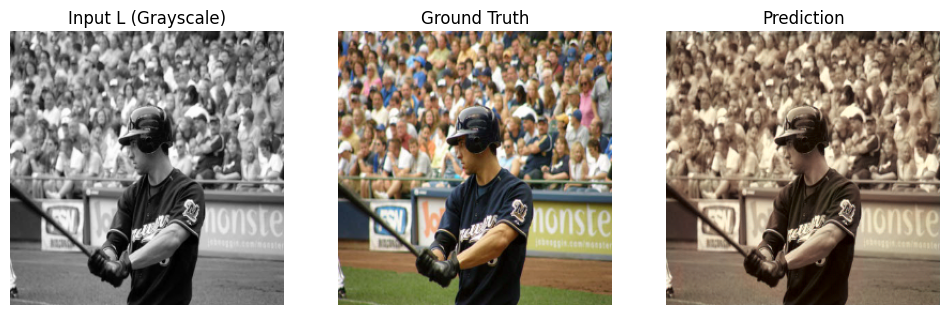

In [16]:
show_image_by_index(model, test_dataset,index=7)

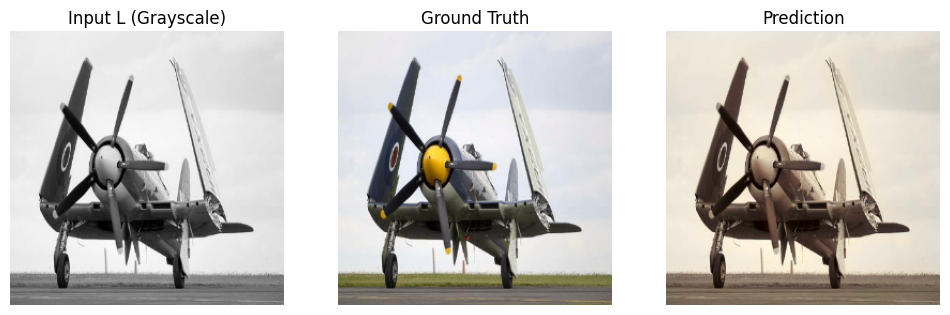

In [17]:
show_image_by_index(model, test_dataset,index=25)

In [18]:
def evaluate_psnr_ssim(model, dataloader, device):
    model.eval()
    psnr_list = []
    ssim_list = []

    with torch.no_grad():
        for L, ab_true in dataloader:
            L = L.to(device)
            ab_true = ab_true.to(device)

            ab_pred = model(L)

            # Loop images
            for i in range(L.size(0)):

                ab_gt_img = ab_true[i].cpu().numpy().transpose(1,2,0)   # (256,256,2)
                ab_pd_img = ab_pred[i].cpu().numpy().transpose(1,2,0)

                # PSNR & SSIM on ab only
                psnr_val = peak_signal_noise_ratio(
                    ab_gt_img, ab_pd_img, data_range=2.0
                )
                ssim_val = structural_similarity(
                    ab_gt_img, ab_pd_img, channel_axis=2, data_range=2.0
                )

                psnr_list.append(psnr_val)
                ssim_list.append(ssim_val)

    return np.mean(psnr_list), np.mean(ssim_list)

In [ ]:
avg_psnr, avg_ssim = evaluate_psnr_ssim(model, test_loader, device)

print("Average PSNR:", avg_psnr)
print("Average SSIM:", avg_ssim)